In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [212]:
data= pd.read_csv("/content/Telco-CustomerChurn_Uncleaned.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4597-NUCQV,Male,1,No,No,24,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,101.25,2440.15,Yes
1,9426-SXNHE,Female,0,No,No,2,Yes,No,NaN,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),18.75,53.15,No
2,2379-GYFLQ,Male,0,No,No,46,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,No,1 Year,Yes,Credit card (automatic),94.90,4422.95,No
3,3506-LCJDC,Male,0,Yes,Yes,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),19.95,19.95,Yes
4,4374-YMUSQ,Male,0,No,No,34,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),116.25,3899.05,No


In [213]:
data.shape

(7143, 21)

In [214]:
print(data.describe())
print('---'*20)
data.info()

       SeniorCitizen  tenure  MonthlyCharges
count        7143.00 7143.00         7082.00
mean            0.16   32.37           64.50
std             0.37   24.56           30.50
min             0.00    0.00         -117.50
25%             0.00    9.00           35.16
50%             0.00   29.00           70.25
75%             0.00   55.00           89.85
max             1.00   72.00          118.75
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7143 entries, 0 to 7142
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7143 non-null   object 
 1   gender            7063 non-null   object 
 2   SeniorCitizen     7143 non-null   int64  
 3   Partner           7143 non-null   object 
 4   Dependents        7143 non-null   object 
 5   tenure            7143 non-null   int64  
 6   PhoneService      7143 non-null   object 
 7  

In [215]:
data.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7138,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7139,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7140,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7141,False,True,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False


In [216]:
data.isnull().sum()

,0
customerID,0
gender,80
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,71
OnlineSecurity,0


To clean the data

In [217]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [218]:
data['MonthlyCharges'].fillna(data['MonthlyCharges'].median(), inplace=True)

In [219]:
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)

In [220]:
categorical_cols = ['gender', 'InternetService', 'Contract', 'PaymentMethod']
for col in categorical_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

In [221]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [222]:
data.shape

(7143, 21)

In [223]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7143 entries, 0 to 7142
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7143 non-null   object 
 1   gender            7143 non-null   object 
 2   SeniorCitizen     7143 non-null   int64  
 3   Partner           7143 non-null   object 
 4   Dependents        7143 non-null   object 
 5   tenure            7143 non-null   int64  
 6   PhoneService      7143 non-null   object 
 7   MultipleLines     7143 non-null   object 
 8   InternetService   7143 non-null   object 
 9   OnlineSecurity    7143 non-null   object 
 10  OnlineBackup      7143 non-null   object 
 11  DeviceProtection  7143 non-null   object 
 12  TechSupport       7143 non-null   object 
 13  StreamingTV       7143 non-null   object 
 14  StreamingMovies   7143 non-null   object 
 15  Contract          7143 non-null   object 
 16  PaperlessBilling  7143 non-null   object 


In [224]:
data.to_csv("Telco-Customer-Churn.csv", index=False)

Outliers

Min-Max Scaling (Normalization):
This scales all numerical values to be between 0 and 1.

In [225]:
from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = MinMaxScaler()
data[cols_to_scale] = scaler.fit_transform(data[cols_to_scale])
data[cols_to_scale].head()

,tenure,MonthlyCharges,TotalCharges
0,0.33,0.93,0.28
1,0.03,0.58,0.00
2,0.64,0.90,0.51
3,0.01,0.58,0.00
4,0.47,0.99,0.45


Standard Scaling (Z-Score Standardization):
This centers the data around a mean of 0 with a standard deviation of 1

In [226]:
from sklearn.preprocessing import StandardScaler


cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
data[cols_to_scale] = scaler.fit_transform(data[cols_to_scale])
data[cols_to_scale].head()

,tenure,MonthlyCharges,TotalCharges
0,-0.34,1.21,0.07
1,-1.24,-1.51,-0.98
2,0.56,1.00,0.95
3,-1.28,-1.47,-1.00
4,0.07,1.70,0.72


Outliers Detction Using BoxPlot:

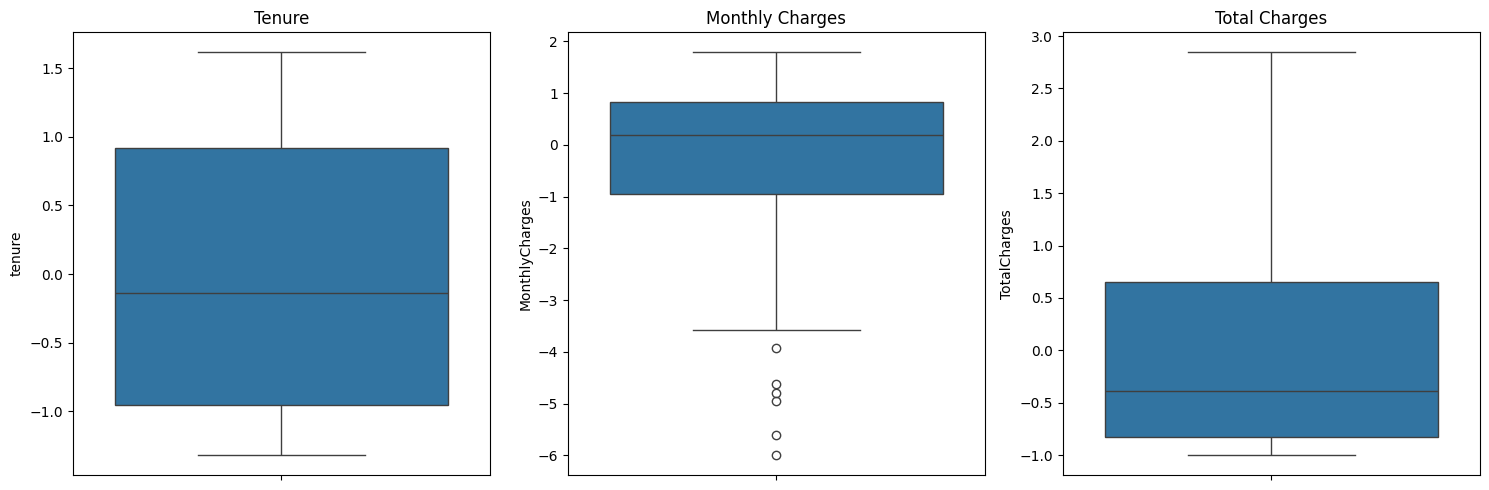

In [227]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=data['tenure'])
plt.title('Tenure')

plt.subplot(1, 3, 2)
sns.boxplot(y=data['MonthlyCharges'])
plt.title('Monthly Charges')

plt.subplot(1, 3, 3)
sns.boxplot(y=data['TotalCharges'])
plt.title('Total Charges')

plt.tight_layout()
plt.show()

In [228]:
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in cols:
    data = data[(data[col] < 3) & (data[col] > -3)]
print(f"Data shape after Z-score outlier removal: {data.shape}")

Data shape after Z-score outlier removal: (7135, 21)


In [229]:
data.to_csv("Telco-Customer-Churn-.csv", index=False)